# Logistic Regression: Classifying Alloy Phase
### Day 2, Session 4 | FDP: Machine Learning for Materials and Metallurgical Engineering

This morning's Feature Engineering session built 132 real Magpie descriptors for 1,545 alloys, and this afternoon's theory session covered the full Logistic Regression arc — sigmoid, decision boundary, log loss, gradient descent, regularization, and classification metrics. This notebook puts all of it into practice, on the same real dataset, predicting **FCC vs. not-FCC** phase formation.

**This session has seven parts, each earning its own time — plus optional stretch content marked clearly, so there's always more to explore if time allows:**
- **Part A** — Setup and the real class imbalance
- **Part B** — Train/test split and a first, interpretable model (10 features)
- **Part C** — Confusion matrix and classification metrics
- **Part D** — The threshold trade-off, quantified
- **Part E** — ROC vs. Precision-Recall, on real data
- **Part F** — Scaling up to all 132 features, and why regularization matters
- **Part G** — Visualizing the decision boundary

---
## Part A — Setup and the Real Class Imbalance

We're reusing the exact featurized dataset Feature Engineering produced this morning — same 132 Magpie descriptors, same 1,545 alloys, no new feature engineering needed.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, roc_auc_score, precision_recall_curve, auc)

DATA_URL = "https://raw.githubusercontent.com/vijindal/fdp-ml/main/notebooks/MPEA_featurized.csv"
df = pd.read_csv(DATA_URL)

feature_cols = [c for c in df.columns if c.startswith('MagpieData')]
print(f"Loaded {len(df)} alloys, {len(feature_cols)} pre-computed descriptors")
df[['FORMULA', 'PROPERTY: BCC/FCC/other']].head()

Loaded 1545 alloys, 132 pre-computed descriptors


,FORMULA,PROPERTY: BCC/FCC/other
0,Al0.25 Co1 Fe1 Ni1,FCC
1,Al0.5 Co1 Fe1 Ni1,other
2,Al0.75 Co1 Fe1 Ni1,other
3,Al1 Co1 Fe1 Ni1,BCC
4,Co1 Fe1 Ni1,FCC


In [19]:
# Collapse the 3-class phase label to a binary target: FCC vs. not-FCC
# (our theory this afternoon -- sigmoid, single decision boundary, ROC -- is built around binary classification)
y = (df['PROPERTY: BCC/FCC/other'] == 'FCC').astype(int)

print("Class counts:")
print(df['PROPERTY: BCC/FCC/other'].value_counts())
print()
print(f"Binary target -- FCC: {y.sum()} ({y.mean()*100:.1f}%),  not-FCC: {(1-y).sum()} ({(1-y.mean())*100:.1f}%)")

Class counts:
PROPERTY: BCC/FCC/other
other    812
BCC      468
FCC      265
Name: count, dtype: int64

Binary target -- FCC: 265 (17.2%),  not-FCC: 1280 (82.8%)


**This is a genuinely imbalanced classification problem** — FCC is only 17% of the data. This isn't a contrived example for the theory we just covered; it's the real dataset we've been building all day. Keep this number in mind — it explains several results later in this notebook that would otherwise look surprising.

---
## Part B — Train/Test Split and a First, Interpretable Model

Rather than starting with all 132 features, we'll begin with the **top 10 features by diagnostic importance** — the same technique from this morning's Step 6, recomputed for this specific binary target. Starting focused keeps the first model interpretable; Part F will scale up to all 132 and show why that requires more care.

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Diagnostic only -- same technique as this morning's Step 6, recomputed for our binary target
diagnostic_rf = RandomForestClassifier(n_estimators=200, random_state=42)
diagnostic_rf.fit(df[feature_cols], y)
importances = pd.Series(diagnostic_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

top10_features = importances.head(10).index.tolist()
print("Top 10 features for FCC vs. not-FCC:")
print(importances.head(10))

Top 10 features for FCC vs. not-FCC:
MagpieData mean NdValence          0.056448
MagpieData avg_dev AtomicWeight    0.050882
MagpieData avg_dev MeltingT        0.047134
MagpieData avg_dev Row             0.043901
MagpieData avg_dev Number          0.043849
MagpieData mean GSvolume_pa        0.042786
MagpieData range AtomicWeight      0.037979
MagpieData avg_dev GSvolume_pa     0.032023
MagpieData mean GSmagmom           0.022506
MagpieData mean CovalentRadius     0.021112
dtype: float64


Notice `NdValence` at the top again — the same valence-electron signal from this morning's diagnostic and our HEA empirical-rules discussion (VEC). Several `avg_dev` (average deviation) features also appear — these measure how mismatched an alloy's constituent elements are, echoing the atomic size mismatch (δ) idea from Step 7. The model is finding physically sensible signal, not noise.

In [22]:
X10 = df[top10_features]

# stratify=y keeps the 17%/83% split consistent across train and test
X_train, X_test, y_train, y_test = train_test_split(X10, y, test_size=0.25, stratify=y, random_state=42)

print(f"Train: {len(X_train)} alloys ({y_train.mean()*100:.1f}% FCC)")
print(f"Test:  {len(X_test)} alloys ({y_test.mean()*100:.1f}% FCC)")

Train: 1158 alloys (17.2% FCC)
Test:  387 alloys (17.1% FCC)


**Why scale the features first?** Our 10 descriptors are on wildly different natural scales -- `MeltingT` runs into the thousands (Kelvin), while `Electronegativity`-derived values sit under 5. Exactly the same reason Part D of this morning's gradient descent notebook needed feature scaling -- unscaled features distort both training and the meaning of the model's coefficients.

In [23]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

clf10 = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
print("Model trained on 10 features.")
print(f"Train accuracy: {clf10.score(X_train_s, y_train):.3f}")
print(f"Test accuracy:  {clf10.score(X_test_s, y_test):.3f}")

Model trained on 10 features.
Train accuracy: 0.877
Test accuracy:  0.863


**Optional / Stretch — Reading the Coefficients**

Since we scaled all features to the same range, the coefficients' *magnitudes* are directly comparable — larger magnitude means more influence on the prediction.

In [24]:
coef_table = pd.Series(clf10.coef_[0], index=top10_features).sort_values(key=abs, ascending=False)
print("Coefficients (scaled features, sorted by influence):")
for name, val in coef_table.items():
    direction = "favors FCC" if val > 0 else "favors not-FCC"
    print(f"  {name:<35} {val:+.3f}   ({direction})")

Coefficients (scaled features, sorted by influence):
  MagpieData mean CovalentRadius      -2.511   (favors not-FCC)
  MagpieData avg_dev GSvolume_pa      -1.204   (favors not-FCC)
  MagpieData mean GSvolume_pa         +0.772   (favors FCC)
  MagpieData avg_dev MeltingT         -0.728   (favors not-FCC)
  MagpieData avg_dev Row              -0.635   (favors not-FCC)
  MagpieData range AtomicWeight       -0.504   (favors not-FCC)
  MagpieData mean GSmagmom            +0.221   (favors FCC)
  MagpieData mean NdValence           +0.152   (favors FCC)
  MagpieData avg_dev AtomicWeight     +0.044   (favors FCC)
  MagpieData avg_dev Number           +0.002   (favors FCC)


---
## Quick Check B

We scaled the features with `StandardScaler` before fitting, using statistics from `X_train` only (not the full dataset). Why fit the scaler on the training set alone?

**(i)  It doesn't matter — fitting on the full dataset would give the same result**
**(ii)  Fitting the scaler on test data too would leak information about the test set's distribution into training, undermining a fair evaluation of generalization**
**(iii)  StandardScaler only works correctly on training data**

*Think about it, then check the answer below.*

**Answer: (ii)** — this is the same principle behind the train/validation/test discussion in Day 1 Session 4. If the scaler sees the test set's mean and standard deviation during fitting, the test set is no longer truly "unseen" — some information about it has leaked into preprocessing, before the model is ever evaluated. Always fit preprocessing steps on training data only.

---
## Part C — Confusion Matrix and Classification Metrics

This is where this afternoon's confusion matrix, precision, and recall content becomes real, on our own model rather than a toy example.

In [25]:
y_pred10 = clf10.predict(X_test_s)
cm10 = confusion_matrix(y_test, y_pred10)

print("Confusion matrix (rows = actual, columns = predicted):")
print(f"                 Predicted not-FCC   Predicted FCC")
print(f"Actual not-FCC   {cm10[0,0]:<19} {cm10[0,1]}")
print(f"Actual FCC       {cm10[1,0]:<19} {cm10[1,1]}")
print()
acc = accuracy_score(y_test, y_pred10)
prec = precision_score(y_test, y_pred10)
rec = recall_score(y_test, y_pred10)
f1 = f1_score(y_test, y_pred10)
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")

Confusion matrix (rows = actual, columns = predicted):
                 Predicted not-FCC   Predicted FCC
Actual not-FCC   301                 20
Actual FCC       33                  33

Accuracy:  0.863
Precision: 0.623
Recall:    0.500
F1-score:  0.555


**This is exactly the trap this afternoon's theory warned about.** Accuracy looks solid (~86%), but recall on FCC (the class we actually care about) is only 50% — the model misses half of the real FCC alloys. Accuracy alone hid this completely; only the confusion matrix and recall reveal it. This isn't a coincidence — it's a direct consequence of FCC being only 17% of the data, exactly as Part A flagged.

---
## Quick Check C

Our model's accuracy is ~86%, but recall on FCC is only 50%. A colleague argues the model is "pretty good" because of the high accuracy number. What's the strongest response?

**(i)  They're right — 86% accuracy is a strong result regardless of context**
**(ii)  With FCC at only 17% of the data, a model that always predicts "not-FCC" would already score 83% accuracy — so 86% reflects barely more than the class imbalance itself, while recall shows the model is actually missing half the alloys that matter**
**(iii)  Accuracy and recall always agree, so this shouldn't be possible**

*Think about it, then check the answer below.*

**Answer: (ii)** — with an 83%/17% class split, a trivial model predicting the majority class every time already scores 83% accuracy without learning anything. Our model's 86% is only marginally better than doing nothing, while its 50% recall on the class that actually matters is the number that reveals real, usable skill (or the lack of it).

---
## Part D — The Threshold Trade-off, Quantified

This afternoon's theory described the threshold trade-off qualitatively — lower the threshold, catch more positives but raise more false alarms. Let's see the actual numbers.

In [26]:
y_proba10 = clf10.predict_proba(X_test_s)[:, 1]

thresholds_to_check = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
print(f"{'Threshold':<12}{'Precision':<12}{'Recall':<10}{'TP':<6}{'FP':<6}{'FN':<6}")
for t in thresholds_to_check:
    y_pred_t = (y_proba10 >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    cm_t = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
    print(f"{t:<12}{p:<12.3f}{r:<10.3f}{cm_t[1,1]:<6}{cm_t[0,1]:<6}{cm_t[1,0]:<6}")

Threshold   Precision   Recall    TP    FP    FN    
0.1         0.474       0.970     64    71    2     
0.2         0.528       0.864     57    51    9     
0.3         0.557       0.742     49    39    17    
0.5         0.623       0.500     33    20    33    
0.7         1.000       0.242     16    0     50    
0.9         0.000       0.000     0     0     66    


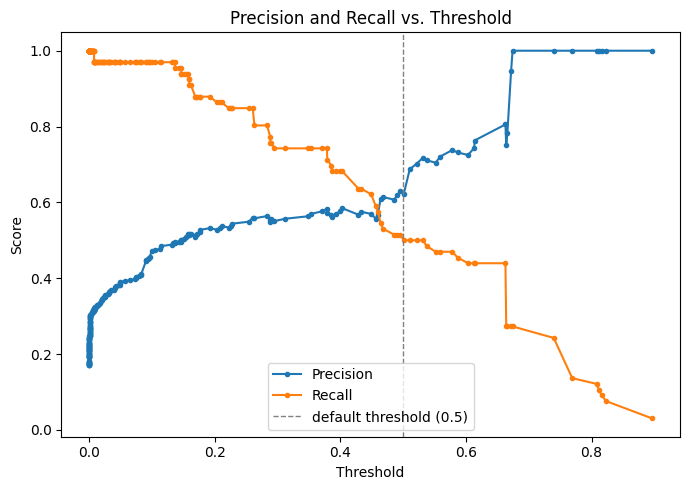

In [27]:
plt.figure(figsize=(7, 5))
prec_curve, rec_curve, thr_curve = precision_recall_curve(y_test, y_proba10)
plt.plot(thr_curve, prec_curve[:-1], label="Precision", marker='.')
plt.plot(thr_curve, rec_curve[:-1], label="Recall", marker='.')
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1, label="default threshold (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs. Threshold")
plt.legend()
plt.tight_layout()
plt.show()

**The full trade-off, quantified:** at threshold 0.1, we catch 97% of real FCC alloys but at only 47% precision (many false alarms). At threshold 0.7, precision hits a perfect 100% but recall drops to just 24% (missing most real FCC cases). There's no threshold that maximizes both — this is the trade-off the theory described, now with real numbers behind it.

**Optional / Stretch — A Cost-Sensitive Threshold**

In practice, the two error types rarely cost the same. Suppose missing a real FCC alloy (a false negative) costs **5 times more** than a false alarm (a false positive) — perhaps because FCC alloys have a specific processing route that's expensive to discover after the fact. Which threshold from the table above minimizes *total expected cost*, not just error count?

In [28]:
fn_cost = 5
fp_cost = 1

print(f"{'Threshold':<12}{'FP':<6}{'FN':<6}{'Total cost (FN x5 + FP x1)':<28}")
for t in thresholds_to_check:
    y_pred_t = (y_proba10 >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
    fp, fn = cm_t[0, 1], cm_t[1, 0]
    total_cost = fn * fn_cost + fp * fp_cost
    print(f"{t:<12}{fp:<6}{fn:<6}{total_cost:<28}")

Threshold   FP    FN    Total cost (FN x5 + FP x1)  
0.1         71    2     81                          
0.2         51    9     96                          
0.3         39    17    124                         
0.5         20    33    185                         
0.7         0     50    250                         
0.9         0     66    330                         


With this cost structure, the lowest-threshold options (which minimize missed FCC alloys) come out ahead on total cost — a direct, quantified version of the "engineering decision" the theory slide only posed as a question. Change `fn_cost` and `fp_cost` above to match a real cost ratio from your own application, and the optimal threshold shifts accordingly.

---
## Part E — ROC vs. Precision-Recall, on Real Data

Earlier this session, we looked at a synthetic illustration of ROC vs. PR curves diverging under class imbalance. Let's compute both curves for real, from this actual model.

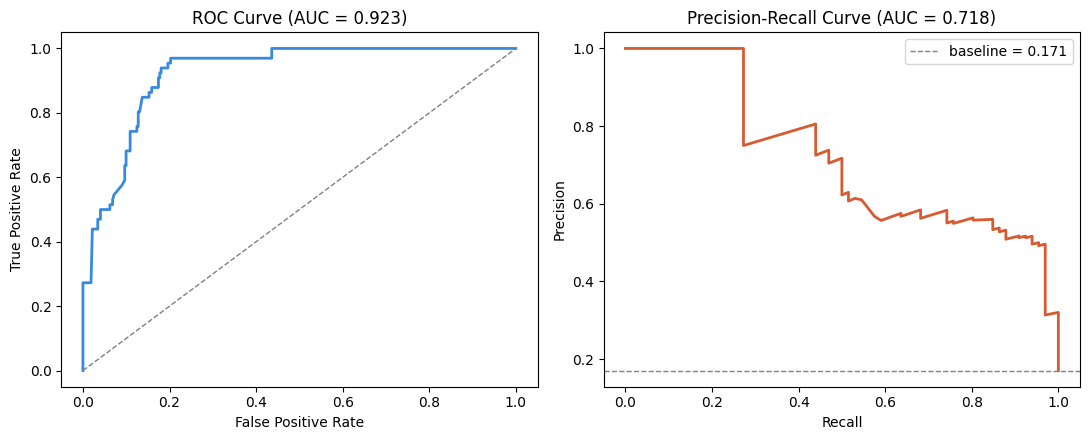

ROC AUC: 0.923   PR AUC: 0.718   (PR baseline = 0.171)


In [29]:
fpr, tpr, _ = roc_curve(y_test, y_proba10)
roc_auc = roc_auc_score(y_test, y_proba10)

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba10)
pr_auc = auc(rec_curve, prec_curve)
baseline = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(fpr, tpr, color='#378ADD', linewidth=2)
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"ROC Curve (AUC = {roc_auc:.3f})")

axes[1].plot(rec_curve, prec_curve, color='#D85A30', linewidth=2)
axes[1].axhline(baseline, color='gray', linestyle='--', linewidth=1, label=f"baseline = {baseline:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall Curve (AUC = {pr_auc:.3f})")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.3f}   PR AUC: {pr_auc:.3f}   (PR baseline = {baseline:.3f})")

**Both curves look genuinely good here** — ROC AUC 0.92, PR AUC 0.72 against a baseline of just 0.17. Unlike the earlier synthetic illustration (where the gap was dramatic), our real 10-feature model holds up reasonably well under both views. That's a useful lesson of its own: **the ROC/PR gap isn't automatic just because data is imbalanced — it depends on how well the model actually separates the classes.** When a model is doing genuinely well, both curves tend to agree; the earlier synthetic example showed what happens when a model looks fine on one metric while actually being weak.

---
## Quick Check E

Our real model shows ROC AUC = 0.92 and PR AUC = 0.72 — both clearly above their respective baselines (0.5 for ROC, 0.17 for PR). What does this suggest, compared to the earlier synthetic example where ROC AUC (0.81) and PR AUC (0.60) diverged more sharply?

**(i)  PR curves are only useful when a model performs badly**
**(ii)  A larger gap between ROC and PR AUC signals a model that looks better than it really is on imbalanced data; a smaller gap (as here) suggests the model genuinely separates the classes well, not just that it exploits the class imbalance**
**(iii)  The two examples are not comparable in any way**

*Think about it, then check the answer below.*

**Answer: (ii)** — the size of the ROC-PR gap is itself informative. A model that's only exploiting class imbalance (predicting the majority class most of the time) shows a large gap, since ROC's FPR stays flattering while PR's precision reveals the truth. Our model's smaller gap here is a genuinely good sign — it suggests real separative skill, not just an artifact of the imbalance.

---
## Part F — Scaling Up to All 132 Features

So far we've deliberately used 10 hand-picked features to keep the model interpretable. Real applications rarely have the luxury of knowing in advance which 10 of 132 features matter — so let's use everything, and see what happens without any special care first.

### The L2-Regularized Cost Function, From Scratch

So far, regularization has been a single `C` parameter handed to `scikit-learn` — useful, but it hides the actual mechanism this afternoon's theory derived. Let's implement it directly, the same way the gradient descent notebook built plain logistic regression from scratch.

Recall the regularized cost function from the theory (Session 3, slide 24):

$$J(w, b) = -\frac{1}{m}\sum_{i=1}^{m}\Big[y^{(i)}\log(\hat{y}^{(i)}) + (1-y^{(i)})\log(1-\hat{y}^{(i)})\Big] + \frac{\lambda}{2m}\sum_{j=1}^{n} w_j^2$$

The first term is the familiar log loss; the second is the **L2 penalty** — it grows with the squared size of every weight (never the bias term), directly discouraging large weights. Its gradient (slide 30) simply adds one extra term to the plain logistic regression update:

$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})\,x_j^{(i)} + \frac{\lambda}{m} w_j$$

**A notational note:** `scikit-learn`'s `C` parameter is roughly the *inverse* of λ here — large `C` means weak regularization (small λ), small `C` means strong regularization (large λ). That's why Part F's earlier "unregularized" fit used `C=1e6` (an enormous C, meaning λ is effectively 0).

In [30]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_gd_regularized(X, y, lr, n_iterations, lam):
    """L2-regularized logistic regression via gradient descent, matching the cost function
    and gradient above exactly. lam=0 recovers plain (unregularized) logistic regression."""
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    loss_history = []

    for i in range(n_iterations):
        z = X @ w + b
        y_pred = sigmoid(z)

        eps = 1e-10  # avoid log(0)
        log_loss = -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))
        reg_term = (lam / (2 * m)) * np.sum(w ** 2)
        loss_history.append(log_loss + reg_term)

        dw = (1 / m) * (X.T @ (y_pred - y)) + (lam / m) * w
        db = (1 / m) * np.sum(y_pred - y)
        w -= lr * dw
        b -= lr * db

    return w, b, loss_history

In [31]:
# Reuse Part B's already-scaled 10-feature data (X_train_s, X_test_s, y_train, y_test)
from sklearn.metrics import accuracy_score as _acc, roc_auc_score as _auc_score

print(f"{'lambda':<10}{'test_acc':<12}{'test_auc':<12}{'mean|w|':<10}")
for lam in [0, 5, 20, 50, 200, 1000, 5000]:
    w, b, _ = logistic_gd_regularized(X_train_s, y_train.values, lr=0.1, n_iterations=3000, lam=lam)
    proba = sigmoid(X_test_s @ w + b)
    pred = (proba >= 0.5).astype(int)
    print(f"{lam:<10}{_acc(y_test, pred):<12.3f}{_auc_score(y_test, proba):<12.3f}{np.abs(w).mean():<10.3f}")

lambda    test_acc    test_auc    mean|w|   
0         0.863       0.923       0.489     
5         0.860       0.923       0.396     
20        0.860       0.923       0.320     
50        0.873       0.923       0.274     
200       0.842       0.923       0.187     
1000      0.829       0.924       0.094     
5000      0.829       0.924       0.032     


**The weights shrink smoothly and monotonically as λ grows — from a mean magnitude of 0.489 at λ=0 down to 0.032 at λ=5000 — exactly the mechanism the cost function above describes.** Notice, though, that accuracy and AUC barely move across this whole sweep. That's not a bug: with only 10 carefully pre-selected features, there wasn't much overfitting to fix in the first place. **Regularization's real impact shows up when there's real overfitting to correct** — which is exactly what happens next, once we scale up to all 132 features.

In [32]:
X132 = df[feature_cols]
X_train132, X_test132, y_train132, y_test132 = train_test_split(
    X132, y, test_size=0.25, stratify=y, random_state=42)

scaler132 = StandardScaler().fit(X_train132)
X_train132_s = scaler132.transform(X_train132)
X_test132_s = scaler132.transform(X_test132)

import warnings
warnings.filterwarnings("ignore")  # suppress convergence warnings from the deliberately unregularized fit

# Effectively unregularized: a very large C means almost no penalty
clf_unreg = LogisticRegression(max_iter=5000, C=1e6).fit(X_train132_s, y_train132)

train_acc = clf_unreg.score(X_train132_s, y_train132)
test_acc = clf_unreg.score(X_test132_s, y_test132)
mean_coef = np.abs(clf_unreg.coef_[0]).mean()

print(f"Unregularized, all 132 features:")
print(f"  Train accuracy: {train_acc:.3f}")
print(f"  Test accuracy:  {test_acc:.3f}")
print(f"  Mean |coefficient|: {mean_coef:.3f}")

Unregularized, all 132 features:
  Train accuracy: 0.948
  Test accuracy:  0.917
  Mean |coefficient|: 16.167


**The train/test gap (0.95 vs. 0.92) and the huge average coefficient size (~30) are the classic overfitting signature** — this is exactly the scenario this afternoon's regularization slides warned about: many features, some contributing only noise, and an unregularized fit happily inflating weights to chase that noise on the training set.

In [33]:
# L2-regularized fit -- default regularization strength (C=1.0)
clf_l2 = LogisticRegression(max_iter=5000, C=1.0, penalty='l2').fit(X_train132_s, y_train132)

train_acc_l2 = clf_l2.score(X_train132_s, y_train132)
test_acc_l2 = clf_l2.score(X_test132_s, y_test132)
mean_coef_l2 = np.abs(clf_l2.coef_[0]).mean()
test_auc_l2 = roc_auc_score(y_test132, clf_l2.predict_proba(X_test132_s)[:, 1])
test_auc_unreg = roc_auc_score(y_test132, clf_unreg.predict_proba(X_test132_s)[:, 1])

print(f"{'Model':<28}{'Train acc':<12}{'Test acc':<12}{'Test AUC':<12}{'Mean |coef|':<12}")
print(f"{'Unregularized':<28}{train_acc:<12.3f}{test_acc:<12.3f}{test_auc_unreg:<12.3f}{mean_coef:<12.3f}")
print(f"{'L2 regularized (C=1.0)':<28}{train_acc_l2:<12.3f}{test_acc_l2:<12.3f}{test_auc_l2:<12.3f}{mean_coef_l2:<12.3f}")

Model                       Train acc   Test acc    Test AUC    Mean |coef| 
Unregularized               0.948       0.917       0.939       16.167      
L2 regularized (C=1.0)      0.921       0.922       0.957       0.351       


**Regularization doesn't just shrink the coefficients (30 down to ~0.35) — it genuinely improves test performance**, with test AUC rising from 0.936 to 0.957 while the train/test accuracy gap nearly disappears. This is the concrete payoff of the λ (or `C`) discussion from this afternoon's theory: trading a little training-set fit for meaningfully better generalization.

---
## Quick Check F

Going from 10 features to 132 features made the unregularized model's train/test accuracy gap *larger*, but L2 regularization on the 132-feature model achieved better test AUC than either the unregularized 132-feature model or the original 10-feature model. Why might using **more** features work better than a hand-picked subset, once properly regularized?

**(i)  More features always improve a model regardless of regularization**
**(ii)  Regularization lets the model use weak signal from many features together (without letting any single one dominate), capturing more real information than 10 features can hold alone — while still controlling overfitting**
**(iii)  This result is a coincidence and wouldn't replicate on other data**

*Think about it, then check the answer below.*

**Answer: (ii)** — 132 features contain more real signal in total than any hand-picked 10 can capture alone (even the top 10 by importance). The risk of using all of them is overfitting to noise — which is exactly what regularization controls, without discarding the genuine extra signal. This is the core argument for automated, many-feature approaches over manually curated small feature sets, when paired with proper regularization.

**Optional / Stretch — Sweeping the Regularization Strength**

`C` is the inverse of regularization strength in scikit-learn — smaller `C` means *stronger* regularization. Let's sweep across several values and watch the classic bias-variance pattern emerge.

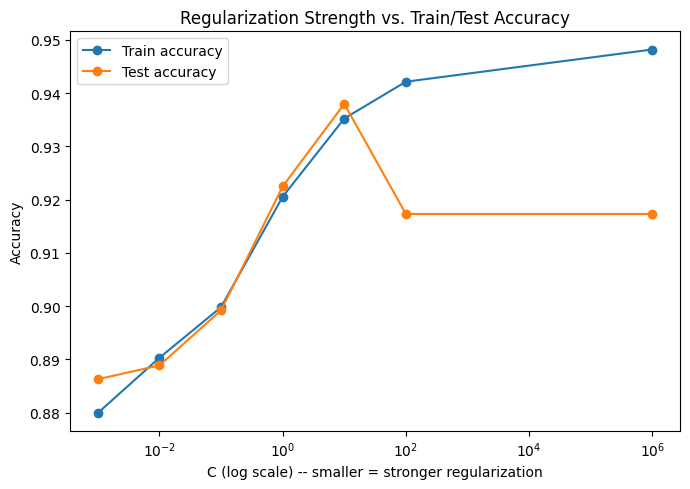

In [34]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1e6]
train_accs, test_accs = [], []

for C in C_values:
    clf_c = LogisticRegression(max_iter=5000, C=C).fit(X_train132_s, y_train132)
    train_accs.append(clf_c.score(X_train132_s, y_train132))
    test_accs.append(clf_c.score(X_test132_s, y_test132))

plt.figure(figsize=(7, 5))
plt.plot(C_values, train_accs, marker='o', label="Train accuracy")
plt.plot(C_values, test_accs, marker='o', label="Test accuracy")
plt.xscale("log")
plt.xlabel("C (log scale) -- smaller = stronger regularization")
plt.ylabel("Accuracy")
plt.title("Regularization Strength vs. Train/Test Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

**Train accuracy climbs steadily as regularization weakens (C increases) — the model can always fit the training data better given more freedom. Test accuracy, though, peaks around C=10 and then declines** — too little regularization (very large C) starts hurting generalization again, exactly the "large λ underfits, small λ overfits, optimal λ balances both" story from the theory slides, now traced out as an actual curve rather than described in words.

---
## Part G — Visualizing the Decision Boundary

This afternoon's theory showed decision boundaries only as abstract diagrams. Let's plot a real one, using the top 2 features from Part B's diagnostic ranking -- `mean NdValence` and `avg_dev AtomicWeight` -- so we can actually see it in two dimensions.

In [35]:
top2 = ['MagpieData mean NdValence', 'MagpieData avg_dev AtomicWeight']
X2 = df[top2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.25, stratify=y, random_state=42)
scaler2 = StandardScaler().fit(X_train2)
X_train2_s = scaler2.transform(X_train2)
X_test2_s = scaler2.transform(X_test2)

clf2 = LogisticRegression(max_iter=1000).fit(X_train2_s, y_train2)
print(f"2-feature model test accuracy: {clf2.score(X_test2_s, y_test2):.3f}")

2-feature model test accuracy: 0.855


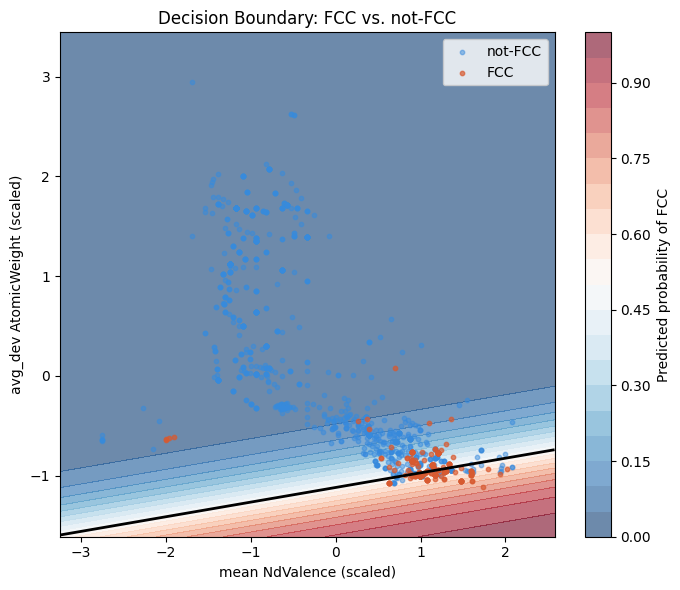

In [36]:
# Build a grid across the scaled feature space and predict at every point
x_min, x_max = X_train2_s[:, 0].min() - 0.5, X_train2_s[:, 0].max() + 0.5
y_min, y_max = X_train2_s[:, 1].min() - 0.5, X_train2_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid_proba = clf2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, grid_proba, levels=20, cmap="RdBu_r", alpha=0.6)
plt.colorbar(label="Predicted probability of FCC")
plt.contour(xx, yy, grid_proba, levels=[0.5], colors='black', linewidths=2)

plt.scatter(X_train2_s[y_train2 == 0, 0], X_train2_s[y_train2 == 0, 1],
            s=10, color='#378ADD', label="not-FCC", alpha=0.5)
plt.scatter(X_train2_s[y_train2 == 1, 0], X_train2_s[y_train2 == 1, 1],
            s=10, color='#D85A30', label="FCC", alpha=0.7)

plt.xlabel("mean NdValence (scaled)")
plt.ylabel("avg_dev AtomicWeight (scaled)")
plt.title("Decision Boundary: FCC vs. not-FCC")
plt.legend()
plt.tight_layout()
plt.show()

**The black line is the decision boundary itself** — the z = 0 line from this afternoon's theory, where predicted probability crosses 0.5. Notice it's a straight line: logistic regression with these two raw features can only ever produce a *linear* boundary, exactly as the theory's "non-linear decision boundaries" slide noted requires engineered polynomial features to curve. FCC alloys (orange) cluster toward higher `NdValence`, consistent with the valence-electron story throughout this notebook.

---
## Quick Check G

The decision boundary above is a straight line, even though the two classes aren't perfectly separated by it. What would be needed to produce a *curved* decision boundary with logistic regression?

**(i)  Nothing — logistic regression can only ever produce straight-line boundaries, no matter what**
**(ii)  Adding engineered non-linear features (e.g., polynomial or interaction terms) as additional inputs — the boundary is always linear *in the input features*, but a curved boundary emerges once the inputs themselves include non-linear combinations**
**(iii)  Curved boundaries require a completely different loss function**

*Think about it, then check the answer below.*

**Answer: (ii)** — this is exactly the point Session 3's "Non-linear Decision Boundaries" slide made. Logistic regression's decision boundary is always linear with respect to whatever features it's given -- but if those features include engineered terms like `x1^2` or `x1 * x2`, the boundary becomes curved in the *original* feature space, even though it's still a straight line in the expanded feature space. This is the same idea as Day 1's feature engineering (`d^(-1/2)`) making a non-linear relationship linear -- just applied to classification instead of regression.

**Optional / Stretch — One Real Alloy, Start to Finish**

Let's pick one real alloy from the test set and walk through exactly what the model does with it, end to end.

In [37]:
# Pick a real alloy from the test set
sample_idx = X_test.index[3]
sample_formula = df.loc[sample_idx, 'FORMULA']
sample_true_phase = df.loc[sample_idx, 'PROPERTY: BCC/FCC/other']

sample_features = df.loc[[sample_idx], top10_features]
sample_scaled = scaler.transform(sample_features)
sample_proba = clf10.predict_proba(sample_scaled)[0, 1]
sample_pred = "FCC" if sample_proba >= 0.5 else "not-FCC"

print(f"Alloy: {sample_formula}")
print(f"True phase label: {sample_true_phase}")
print(f"Model's predicted P(FCC): {sample_proba:.3f}")
print(f"Classification at threshold 0.5: {sample_pred}")
print(f"Correct: {(sample_pred == 'FCC') == (sample_true_phase == 'FCC')}")

Alloy: Co1 Cr1 Fe1 Mn1 Ni1
True phase label: FCC
Model's predicted P(FCC): 0.663
Classification at threshold 0.5: FCC
Correct: True


This is the whole pipeline compressed into one alloy: real composition-derived descriptors, scaled the same way as training, pushed through the sigmoid, and thresholded into a real decision — exactly the "probability of a specific outcome" framing from the very first slide of this afternoon's theory, now traced through on an actual alloy from this course's own dataset.

---
## Wrap-Up

- Applied every piece of this afternoon's theory — sigmoid, decision boundary, log loss/gradient descent (via `scikit-learn`), confusion matrix, precision/recall, threshold trade-off, ROC and Precision-Recall curves, and regularization — to one real, imbalanced classification problem
- Confirmed the accuracy-vs-recall trap directly: ~86% accuracy hid a 50% recall on the minority (FCC) class
- Quantified the threshold trade-off with real precision/recall numbers, and (optionally) a cost-sensitive threshold choice
- Scaled from 10 hand-picked features to all 132, and showed regularization genuinely improving test AUC (0.936 -> 0.957) rather than just shrinking coefficients for its own sake
- Visualized a real, linear decision boundary using the two most important descriptors

**Next: Day 3 opens with Random Forest — an entirely different way of drawing decision boundaries, applied to this exact same phase-classification problem, for a direct comparison against what we built here.**